In [55]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt

In [56]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

In [57]:
tf.config.experimental.enable_op_determinism()

In [58]:
DATA_DIR = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24"

## Feature Extraction 

In [59]:
def extract_features(file):

    audio, sr = librosa.load(file, sr=22050)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr)

    mel = librosa.power_to_db(mel)

    mel = librosa.util.fix_length(mel, size=128, axis=1)

    return mel

## Dataset Loading

In [60]:
X = []
y = []

for actor in sorted(os.listdir(DATA_DIR)):

    actor_path = os.path.join(DATA_DIR, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in sorted(os.listdir(actor_path)):

        if file.endswith(".wav"):

            file_path = os.path.join(actor_path, file)

            feature = extract_features(file_path)

            X.append(feature)

            emotion = int(file.split("-")[2]) - 1

            y.append(emotion)

X = np.array(X)
y = np.array(y)

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded
X shape: (1440, 128, 128)
y shape: (1440,)


## Convert to CNN input

In [61]:
X = np.expand_dims(X, -1)

X = np.repeat(X, 3, axis=-1)

print("CNN input shape:", X.shape)

CNN input shape: (1440, 128, 128, 3)


## Pretrained CNN Feature Extraction

In [62]:
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

## Build Feature Extractor

In [63]:
IMG_SIZE = (128,128,3)

def build_feature_extractor(model_name):

    if model_name == "mobilenet":

        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=IMG_SIZE
        )

    elif model_name == "resnet":

        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=IMG_SIZE
        )

    base_model.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    model = Model(base_model.input, x)

    return model

In [64]:
mobilenet_extractor = build_feature_extractor("mobilenet")

resnet_extractor = build_feature_extractor("resnet")

## Extract CNN Embeddings

In [65]:
def extract_embeddings(model, X):

    embeddings = model.predict(X, batch_size=32, verbose=1)

    return embeddings

## MobileNet Features

In [66]:
mobilenet_features = extract_embeddings(mobilenet_extractor, X)

print("MobileNet feature shape:", mobilenet_features.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
MobileNet feature shape: (1440, 1280)


## ResNet Features

In [67]:
resnet_features = extract_embeddings(resnet_extractor, X)

print("ResNet feature shape:", resnet_features.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
ResNet feature shape: (1440, 2048)


## Combine Embeddings

In [68]:
features = np.concatenate([mobilenet_features, resnet_features], axis=1)

print("Combined feature shape:", features.shape)

Combined feature shape: (1440, 3328)


In [69]:
np.save("cnn_embeddings.npy", features)
np.save("labels.npy", y)

## Fine-Tuning MobileNetV2

In [70]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [71]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [72]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(len(np.unique(y)), activation="softmax")(x)

fine_tuned_model = Model(base_model.input, outputs)

In [73]:
fine_tuned_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [76]:
history = fine_tuned_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.2763 - loss: 1.9426 - val_accuracy: 0.2674 - val_loss: 2.0627
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6171 - loss: 1.0664 - val_accuracy: 0.2569 - val_loss: 2.0501
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7637 - loss: 0.7841 - val_accuracy: 0.2639 - val_loss: 2.0430
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8458 - loss: 0.5728 - val_accuracy: 0.2396 - val_loss: 2.0695
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9207 - loss: 0.3924 - val_accuracy: 0.2396 - val_loss: 2.1281
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9573 - loss: 0.2737 - val_accuracy: 0.2292 - val_loss: 2.1573


In [77]:
loss, acc = fine_tuned_model.evaluate(X_test, y_test)

print("Fine-tuned CNN Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2580 - loss: 2.1078
Fine-tuned CNN Accuracy: 0.2638888955116272


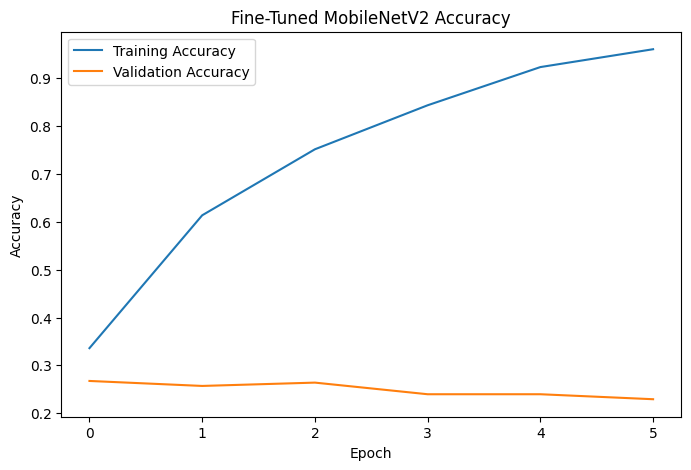

In [78]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Fine-Tuned MobileNetV2 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

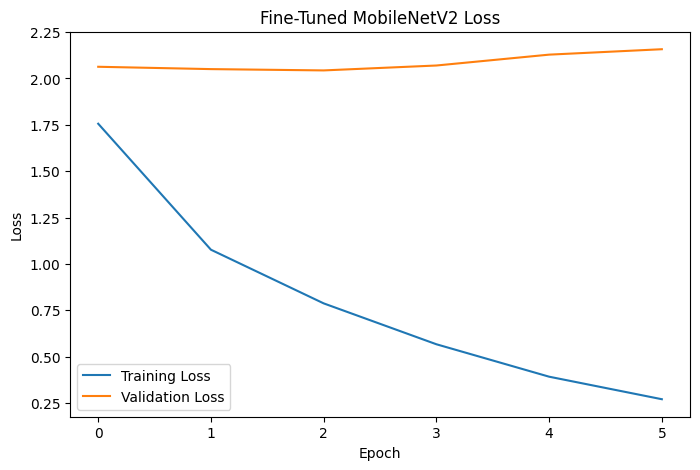

In [79]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Fine-Tuned MobileNetV2 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

## Temporal Sequence Pipeline

In [80]:
SEQ_LENGTH = 10

In [81]:
def create_sequences(features, labels, seq_len):

    X_seq = []
    y_seq = []

    for i in range(len(features) - seq_len):

        X_seq.append(features[i:i+seq_len])
        y_seq.append(labels[i+seq_len])

    return np.array(X_seq), np.array(y_seq)

In [82]:
X_seq, y_seq = create_sequences(features, y, SEQ_LENGTH)

print("Sequence shape:", X_seq.shape)
print("Labels shape:", y_seq.shape)

Sequence shape: (1430, 10, 3328)
Labels shape: (1430,)


In [83]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

In [84]:
print("RNN input shape:", X_train_seq.shape)

RNN input shape: (1144, 10, 3328)


## Attention Mechanism

In [85]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

## Attention Layer

In [86]:
class Attention(Layer):

    def build(self, input_shape):

        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1],1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1],1),
            initializer="zeros",
            trainable=True
        )

        super(Attention, self).build(input_shape)

    def call(self, x):

        e = K.tanh(K.dot(x,self.W)+self.b)

        a = K.softmax(e, axis=1)

        output = x * a

        return K.sum(output, axis=1)

## RNN Model

In [87]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, Dense

In [88]:
def build_rnn_model():

    inputs = Input(shape=(SEQ_LENGTH, features.shape[1]))

    x = SimpleRNN(128, return_sequences=True)(inputs)

    x = Attention()(x)

    x = Dense(64, activation="relu")(x)

    outputs = Dense(len(np.unique(y)), activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## LSTM Model

In [89]:
from tensorflow.keras.layers import LSTM

In [90]:
def build_lstm_model():

    inputs = Input(shape=(SEQ_LENGTH, features.shape[1]))

    x = LSTM(128, return_sequences=True)(inputs)

    x = Attention()(x)

    x = Dense(64, activation="relu")(x)

    outputs = Dense(len(np.unique(y)), activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## GRU Model

In [91]:
from tensorflow.keras.layers import GRU

In [92]:
def build_gru_model():

    inputs = Input(shape=(SEQ_LENGTH, features.shape[1]))

    x = GRU(128, return_sequences=True)(inputs)

    x = Attention()(x)

    x = Dense(64, activation="relu")(x)

    outputs = Dense(len(np.unique(y)), activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [93]:
rnn_model = build_rnn_model()

lstm_model = build_lstm_model()

gru_model = build_gru_model()

## Train RNN

In [94]:
from tensorflow.keras.callbacks import EarlyStopping

In [95]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [96]:
history_rnn = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


2026-03-04 16:44:15.794084: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2351 - loss: 2.0700 - val_accuracy: 0.4441 - val_loss: 1.4937
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4709 - loss: 1.4075 - val_accuracy: 0.5734 - val_loss: 1.1557
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6158 - loss: 1.0794 - val_accuracy: 0.6364 - val_loss: 0.9838
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7048 - loss: 0.8629 - val_accuracy: 0.7098 - val_loss: 0.8419
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7673 - loss: 0.7103 - val_accuracy: 0.7552 - val_loss: 0.6857
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8151 - loss: 0.5714 - val_accuracy: 0.7972 - val_loss: 0.5586
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8463 - loss: 0.4585 - val_accuracy: 0.8252 - val_loss: 0.4522
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8988 - loss: 0.3240 - val_accuracy: 0.8636 - val_loss: 0.

## Train LSTM

In [97]:
history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


2026-03-04 16:44:28.255068: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2482 - loss: 1.9711 - val_accuracy: 0.4965 - val_loss: 1.6028
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5156 - loss: 1.4617 - val_accuracy: 0.5944 - val_loss: 1.2166
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6500 - loss: 1.0608 - val_accuracy: 0.7133 - val_loss: 0.8674
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7744 - loss: 0.7386 - val_accuracy: 0.7448 - val_loss: 0.6984
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8665 - loss: 0.5070 - val_accuracy: 0.8077 - val_loss: 0.5294
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8955 - loss: 0.3926 - val_accuracy: 0.8182 - val_loss: 0.4716
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9004 - loss: 0.3338 - val_accuracy: 0.8462 - val_loss: 0.4346
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9305 - loss: 0.2677 - val_accuracy: 0.8531 - val_loss: 0.

## Train GRU

In [98]:
history_gru = gru_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


2026-03-04 16:44:37.326200: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2204 - loss: 1.9893 - val_accuracy: 0.5664 - val_loss: 1.4334
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5497 - loss: 1.3041 - val_accuracy: 0.6538 - val_loss: 1.0420
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7051 - loss: 0.9203 - val_accuracy: 0.7413 - val_loss: 0.7634
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8138 - loss: 0.6209 - val_accuracy: 0.7937 - val_loss: 0.5834
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8635 - loss: 0.4287 - val_accuracy: 0.8566 - val_loss: 0.4415
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9187 - loss: 0.3093 - val_accuracy: 0.8531 - val_loss: 0.3960
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9268 - loss: 0.2510 - val_accuracy: 0.8706 - val_loss: 0.3526
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9471 - loss: 0.2123 - val_accuracy: 0.8462 - val_loss: 0.

## Hyperparameter Tuning

In [112]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np

num_classes = len(np.unique(y_train))

learning_rates = [0.001, 0.0001]
units_list = [64, 128, 256]

results = []

for lr in learning_rates:
    for units in units_list:

        model = Sequential()

        model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

        model.add(GRU(units))

        model.add(Dense(64, activation="relu"))

        model.add(Dense(num_classes, activation="softmax"))

        optimizer = Adam(learning_rate=lr)

        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            X_train_seq,
            y_train,
            epochs=10,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        best_acc = max(history.history["val_accuracy"])

        results.append({
            "Learning Rate": lr,
            "Units": units,
            "Validation Accuracy": best_acc
        })

2026-03-04 16:53:30.163609: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-03-04 16:53:36.067298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

In [130]:
results_df.columns = ["Learning Rate", "GRU Units", "Validation Accuracy"]

results_df

,Learning Rate,GRU Units,Validation Accuracy
0,0.0010,64,0.196507
1,0.0010,128,0.174672
2,0.0010,256,0.183406
3,0.0001,64,0.148472
4,0.0001,128,0.113537
5,0.0001,256,0.152838


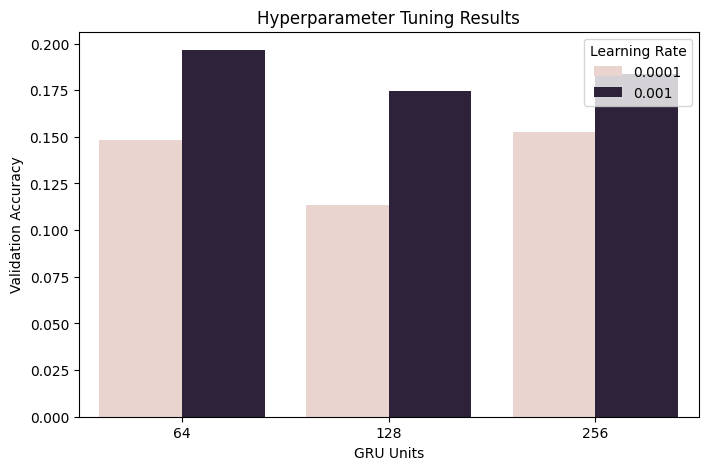

In [131]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="GRU Units",
    y="Validation Accuracy",
    hue="Learning Rate",
    data=results_df
)

plt.title("Hyperparameter Tuning Results")

plt.show()

In [132]:
best_result = results_df.loc[results_df["Validation Accuracy"].idxmax()]

print("Best Hyperparameters:")
print(best_result)

Best Hyperparameters:
Learning Rate           0.001000
GRU Units              64.000000
Validation Accuracy     0.196507
Name: 0, dtype: float64


In [115]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_seq, y_test_seq)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test_seq)

gru_loss, gru_acc = gru_model.evaluate(X_test_seq, y_test_seq)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8745 - loss: 0.3162


2026-03-04 16:54:43.455813: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8358 - loss: 0.3682 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8819 - loss: 0.2759 


In [116]:
experiment_table = pd.DataFrame({

"Model": ["RNN", "LSTM", "GRU"],

"Test Accuracy": [rnn_acc, lstm_acc, gru_acc],

"Test Loss": [rnn_loss, lstm_loss, gru_loss],

"Sequence Length": [SEQ_LENGTH, SEQ_LENGTH, SEQ_LENGTH],

"Batch Size": [32, 32, 32],

"Optimizer": ["Adam", "Adam", "Adam"]

})

experiment_table
experiment_table.sort_values("Test Accuracy", ascending=False)

,Model,Test Accuracy,Test Loss,Sequence Length,Batch Size,Optimizer
2,GRU,0.891608,0.262854,10,32,Adam
0,RNN,0.881119,0.284168,10,32,Adam
1,LSTM,0.856643,0.344383,10,32,Adam


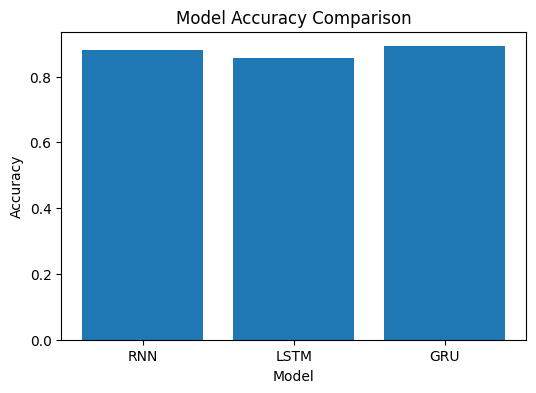

In [118]:
plt.figure(figsize=(6,4))

plt.bar(experiment_table["Model"], experiment_table["Test Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xlabel("Model")

plt.show()

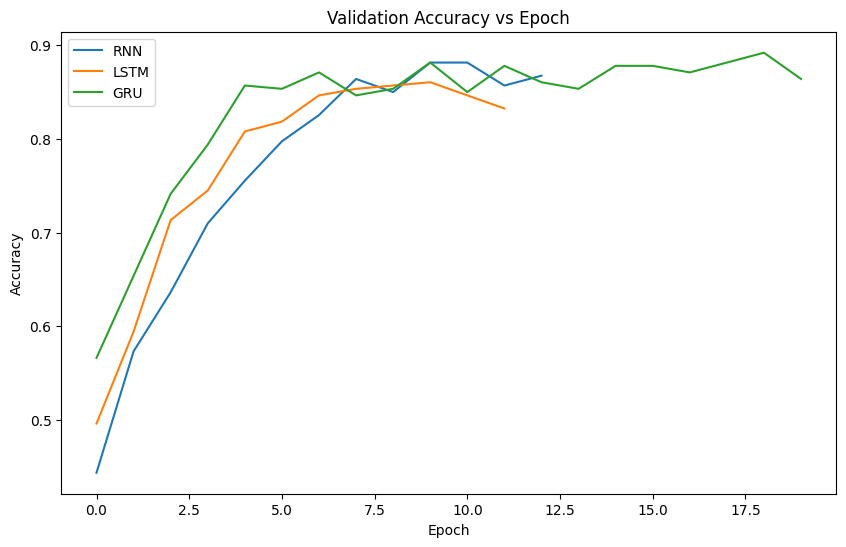

In [119]:
plt.figure(figsize=(10,6))

plt.plot(history_rnn.history["val_accuracy"], label="RNN")

plt.plot(history_lstm.history["val_accuracy"], label="LSTM")

plt.plot(history_gru.history["val_accuracy"], label="GRU")

plt.title("Validation Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

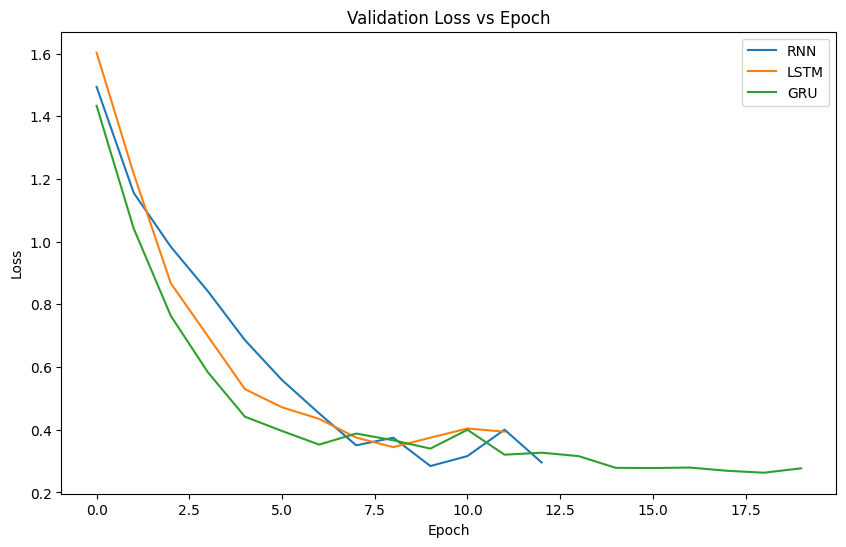

In [120]:
plt.figure(figsize=(10,6))

plt.plot(history_rnn.history["val_loss"], label="RNN")

plt.plot(history_lstm.history["val_loss"], label="LSTM")

plt.plot(history_gru.history["val_loss"], label="GRU")

plt.title("Validation Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [128]:
best_model = max(
    [(rnn_model, rnn_acc),
     (lstm_model, lstm_acc),
     (gru_model, gru_acc)],
    key=lambda x: x[1]
)[0]

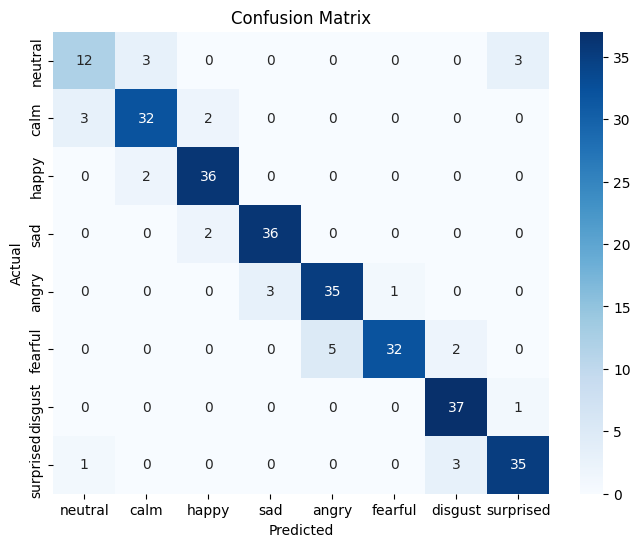

In [129]:
emotion_labels = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised"
]

cm = confusion_matrix(y_test_seq, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()